Aggregate daily variables using a new grid and getting the max

In [1]:
from pathlib import Path
from typing import Dict, Optional, Tuple
import warnings
import zipfile
import xml.etree.ElementTree as ET

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import math
from shapely.geometry import LineString, Polygon, box
from sklearn.cluster import DBSCAN
import os 
import json

CURRENT_VAR = 'sfcWind'

In [2]:
VARIABLES_EXTREME_PATH = "ensembles/variables_extremes.json"
with open(VARIABLES_EXTREME_PATH, "r") as f:
    variables_extremes = json.load(f)

In [3]:
def parse_cmip6_filename(filename: str) -> Optional[Dict[str, str]]:
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) < 7:
        return None
    return {
        "variable": parts[0],
        # "table": parts[1],
        "model": parts[2],
        # "experiment": "_".join(parts[3:-3]),
        # "ensemble": parts[-3],
        # "grid": parts[-2],
        "date_range": parts[-1],
    }


def load_inventory(base_path: str) -> pd.DataFrame:
    root = Path(base_path)
    if not root.exists():
        return pd.DataFrame()

    records = []
    for scenario_dir in sorted([d for d in root.iterdir() if d.is_dir()]):
        for nc_file in sorted(scenario_dir.glob("*.nc")):
            meta = parse_cmip6_filename(nc_file.name)
            if meta:
                meta["scenario"] = scenario_dir.name
                meta["filepath"] = str(nc_file)
                records.append(meta)

    return pd.DataFrame(records)


def format_temporal_range_label(date_range: str) -> str:
    parts = str(date_range).split("-")
    if len(parts) == 2 and len(parts[0]) >= 4 and len(parts[1]) >= 4:
        return f"{parts[0][:4]}-{parts[1][:4]}"
    return str(date_range)

data_path =  "cmip6_brazil/daily"
df_inventory = load_inventory(data_path)
var_df = df_inventory[df_inventory["variable"] == CURRENT_VAR].copy()
var_df.loc[:, "date_range"] = var_df.loc[:, "date_range"]\
                                            .apply(format_temporal_range_label)

In [4]:

def parse_kmz_with_attributes(kmz_file: str) -> gpd.GeoDataFrame:
    path = Path(kmz_file)
    if not path.exists():
        raise FileNotFoundError(f"KMZ file not found: {path}")

    ns = {"kml": "http://www.opengis.net/kml/2.2"}
    records = []

    with zipfile.ZipFile(path, "r") as zf:
        with zf.open("doc.kml") as kml:
            tree = ET.parse(kml)
            root = tree.getroot()

            for pm in root.findall(".//kml:Placemark", ns):
                name = pm.findtext("kml:name", default="", namespaces=ns)

                # ExtendedData (important!)
                ext_data = {}
                for data in pm.findall(".//kml:ExtendedData//kml:Data", ns):
                    key = data.attrib.get("name")
                    value = data.findtext("kml:value", default="", namespaces=ns)
                    if key:
                        ext_data[key] = value

                coords_node = pm.find(".//kml:LineString/kml:coordinates", ns)
                if coords_node is None or not coords_node.text:
                    continue

                coords = []
                for token in coords_node.text.strip().split():
                    parts = token.split(",")
                    if len(parts) >= 2:
                        lon, lat = float(parts[0]), float(parts[1])
                        coords.append((lon, lat))

                if len(coords) >= 2:
                    geom = LineString(coords)

                    record = {
                        "name": name,
                        **ext_data,
                        "geometry": geom,
                    }
                    records.append(record)

    if not records:
        raise ValueError("No valid Placemarks found.")

    return gpd.GeoDataFrame(records, crs="EPSG:4326")


def cluster_lines_distance(gdf, eps_km=100):
    gdf = gdf.copy()

    # centroids
    centroids = gdf.geometry.centroid

    # (lat, lon) for haversine
    coords = np.array([(pt.y, pt.x) for pt in centroids])
    coords_rad = np.radians(coords)

    # DBSCAN with haversine
    db = DBSCAN(
        eps=eps_km / 6371.0,  # km → radians
        min_samples=1,
        metric="haversine"
    ).fit(coords_rad)


    gdf["cluster"] = db.labels_
    return gdf

gdf = parse_kmz_with_attributes("ISA ENERGIA BRASIL.kmz")
gdf_clustered = cluster_lines_distance(gdf, eps_km=50)

/tmp/ipykernel_1010358/2432703237.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf.geometry.centroid


In [5]:
def pad_bounds_km(bounds: Tuple[float, float, float, float], pad_km: float = 10.0) -> Tuple[float, float, float, float]:
    lon_min, lat_min, lon_max, lat_max = [float(v) for v in bounds]
    lat_mid = (lat_min + lat_max) / 2.0

    pad_lat = pad_km / 111.0
    cos_lat = max(np.cos(np.deg2rad(lat_mid)), 1e-6)
    pad_lon = pad_km / (111.32 * cos_lat)

    return (
        lon_min - pad_lon,
        lat_min - pad_lat,
        lon_max + pad_lon,
        lat_max + pad_lat,
    )

In [6]:
def coordinate_edges(coord_values: np.ndarray) -> np.ndarray:
    values = np.asarray(coord_values, dtype=float)
    if values.size == 1:
        delta = 0.5
        return np.array([values[0] - delta, values[0] + delta], dtype=float)

    diffs = np.diff(values)
    edges = np.empty(values.size + 1, dtype=float)
    edges[1:-1] = (values[:-1] + values[1:]) / 2.0
    edges[0] = values[0] - diffs[0] / 2.0
    edges[-1] = values[-1] + diffs[-1] / 2.0
    return edges


def build_line_intersection_mask(lat_centers: np.ndarray, lon_centers: np.ndarray, line_union) -> np.ndarray:
    lat_edges = coordinate_edges(lat_centers)
    lon_edges = coordinate_edges(lon_centers)

    cell_geometries, cell_i_lat, cell_i_lon = [], [], []
    for i in range(len(lat_centers)):
        y0, y1 = sorted((float(lat_edges[i]), float(lat_edges[i + 1])))
        for j in range(len(lon_centers)):
            x0, x1 = sorted((float(lon_edges[j]), float(lon_edges[j + 1])))
            cell_geometries.append(box(x0, y0, x1, y1))
            cell_i_lat.append(i)
            cell_i_lon.append(j)

    cells = gpd.GeoDataFrame(
        {"i_lat": cell_i_lat, "i_lon": cell_i_lon},
        geometry=cell_geometries,
        crs="EPSG:4326",
    )
    selected = cells.loc[cells.intersects(line_union)]
    # selected = cells.loc[cells.intersects(line_union.buffer(0.05))]

    mask = np.zeros((len(lat_centers), len(lon_centers)), dtype=bool)
    if not selected.empty:
        mask[selected["i_lat"].to_numpy(), selected["i_lon"].to_numpy()] = True
    return mask


def subset_da_to_bbox(da: xr.DataArray, lat_name: str, lon_name: str, bounds: Tuple[float, float, float, float]) -> xr.DataArray:
    """Subset DataArray to bounding box. bounds = [lon_min, lat_min, lon_max, lat_max]"""
    
    # 1. Normalizar longitude primeiro
    if float(da[lon_name].max()) > 180:
        da = da.assign_coords({lon_name: (((da[lon_name] + 180) % 360) - 180)}).sortby(lon_name)

    # 2. Definir o envelope (box)
    lon_min, lat_min, lon_max, lat_max = bounds
    lon_min, lat_min = math.floor(lon_min), math.floor(lat_min)
    lon_max, lat_max = math.ceil(lon_max), math.ceil(lat_max)

    # 3. Pegar valores atuais das coordenadas (após normalização)
    # Usamos .values[0] e [-1] para checar a direção sem carregar o array todo
    lats = da[lat_name].values
    lons = da[lon_name].values

    # 4. Lógica de slice para suportar ordens invertidas (Ex: 90 to -90)
    lat_slice = slice(lat_min, lat_max) if lats[0] < lats[-1] else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if lons[0] < lons[-1] else slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})



def build_min_intersection_panel(filepath: str, variable_name: str, bounds, line_union):
    with xr.open_dataset(filepath) as ds:
        if variable_name not in ds.data_vars:
            return None

        da = ds[variable_name]
        lat_name, lon_name = 'lat', 'lon'


        da = subset_da_to_bbox(da, lat_name, lon_name, bounds)
        seconds_in_month = da['time'].dt.days_in_month * 24 * 60 * 60
        da = da * seconds_in_month

        if da.sizes.get(lat_name, 0) == 0 or da.sizes.get(lon_name, 0) == 0:
            return None

        if "time" in da.dims:
            da = da.min(dim="time", skipna=True)


        for dim in list(da.dims):
            if dim not in (lat_name, lon_name):
                da = da.isel({dim: 0})
        
        # Removido: da.squeeze() 

        lat = np.atleast_1d(da[lat_name].values).astype(float)
        lon = np.atleast_1d(da[lon_name].values).astype(float)

        if lat.size == 0 or lon.size == 0:
            return None

        mask = build_line_intersection_mask(lat, lon, line_union)
        if not np.any(mask):
            return None
        
        mask_da = xr.DataArray(mask, coords={lat_name: da[lat_name], lon_name: da[lon_name]}, dims=(lat_name, lon_name))
        da_masked = da.where(mask_da)

        units = da.attrs.get("units", "N/A")
        # Força a matriz a ter 2 dimensões (lat, lon)
        values = np.asarray(da_masked.values, dtype=float).reshape(len(lat), len(lon))

    return {
        "lat": lat,
        "lon": lon,
        "values": values,
        "units": units,
    }




In [7]:
def regrid_by_binning(da, target_lat, target_lon, agg="max"):
    import pandas as pd
    import numpy as np
    
    dlat = target_lat[1] - target_lat[0]
    dlon = target_lon[1] - target_lon[0]

    lat_bins = np.append(target_lat - dlat/2, target_lat[-1] + dlat/2)
    lon_bins = np.append(target_lon - dlon/2, target_lon[-1] + dlon/2)

    df = da.to_dataframe(name="val").reset_index()

    df["lat_bin"] = pd.cut(df["lat"], bins=lat_bins, labels=target_lat,include_lowest=True)
    df["lon_bin"] = pd.cut(df["lon"], bins=lon_bins, labels=target_lon,include_lowest=True)

    if agg == "max":
        df_agg = df.groupby(["time", "lat_bin", "lon_bin"])["val"].max()
    elif agg == "min":
        df_agg = df.groupby(["time", "lat_bin", "lon_bin"])["val"].min()
    else:
        raise ValueError("Unsupported aggregation")

    da_out = df_agg.to_xarray().rename({"lat_bin": "lat", "lon_bin": "lon"})

    return da_out

In [8]:
def get_extent(da, lat_name='lat', lon_name='lon'):
    """Extrai os limites REAIS do DataArray para o imshow"""
    return [da[lon_name].min(), da[lon_name].max(), da[lat_name].min(), da[lat_name].max()]

def subset_da_to_bbox(da: xr.DataArray, lat_name: str, lon_name: str, bounds: Tuple[float, float, float, float]) -> xr.DataArray:
    """Subset DataArray to bounding box. bounds = [lon_min, lat_min, lon_max, lat_max]"""
    
    # 1. Normalizar longitude primeiro
    if float(da[lon_name].max()) > 180:
        da = da.assign_coords({lon_name: (((da[lon_name] + 180) % 360) - 180)}).sortby(lon_name)

    # 2. Definir o envelope (box)
    lon_min, lat_min, lon_max, lat_max = bounds
    lon_min, lat_min = math.floor(lon_min), math.floor(lat_min)
    lon_max, lat_max = math.ceil(lon_max), math.ceil(lat_max)

    # 3. Pegar valores atuais das coordenadas (após normalização)
    # Usamos .values[0] e [-1] para checar a direção sem carregar o array todo
    lats = da[lat_name].values
    lons = da[lon_name].values

    # 4. Lógica de slice para suportar ordens invertidas (Ex: 90 to -90)
    lat_slice = slice(lat_min, lat_max) if lats[0] < lats[-1] else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if lons[0] < lons[-1] else slice(lon_max, lon_min)

    return da.sel({lat_name: lat_slice, lon_name: lon_slice})

Create ensembles:

In [9]:
max_da = -np.inf
min_da = np.inf

for (scenario, date_range), scenario_group in var_df.groupby(['scenario', 'date_range']):
    n_models = len(scenario_group)

    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

    target_lat = np.arange(-35, 7.5, 1.0)
    target_lon = np.arange(285, 324.375, 1.0)
    model_results = []

    for i in range(len(scenario_group)):
        lat_name, lon_name = 'lat','lon'
        
        ds = xr.open_dataset(
            scenario_group.iloc[i]["filepath"], 
            decode_times=time_coder
        )
        
        if isinstance(ds.indexes['time'], xr.CFTimeIndex):
            ds = ds.convert_calendar('standard', align_on='year')
                
        da = ds[CURRENT_VAR]

        ds_interp = da.interp(lat=target_lat, lon=target_lon, method='nearest')
        model_results.append(ds_interp)

        min_da = min(min_da, da.min().item())
        max_da = max(max_da, da.max().item())
        
    ensemble_cube = xr.concat(model_results, dim='model', join="outer")
    ensemble_max = ensemble_cube.max(dim='model', skipna=True) 

    os.makedirs(f"ensembles/{CURRENT_VAR}", exist_ok=True)
    ensemble_max.to_netcdf(f"ensembles/{CURRENT_VAR}/ensemble_max_{scenario}_{date_range}.nc")
    print('Saved ensemble max for', scenario, date_range)

variables_extremes.update({CURRENT_VAR: (min_da, max_da)})

with open(VARIABLES_EXTREME_PATH, "w") as f:
    json.dump(variables_extremes, f)

Saved ensemble max for historical 1995-2014
Saved ensemble max for ssp1_2_6 2021-2040
Saved ensemble max for ssp1_2_6 2031-2050
Saved ensemble max for ssp1_2_6 2041-2060
Saved ensemble max for ssp2_4_5 2021-2040
Saved ensemble max for ssp2_4_5 2031-2050
Saved ensemble max for ssp2_4_5 2041-2060
Saved ensemble max for ssp3_7_0 2021-2040
Saved ensemble max for ssp3_7_0 2031-2050
Saved ensemble max for ssp3_7_0 2041-2060


2. Generate graphs

(0.00026973371859639883, 40.129249572753906)

In [11]:
def get_line_coords(line_union):
    line_coords = []

    if line_union.geom_type == 'MultiLineString':
        for line in line_union.geoms:
            line_coords.append(line.xy)
    else:
        line_coords.append(line_union.xy)
    return line_coords

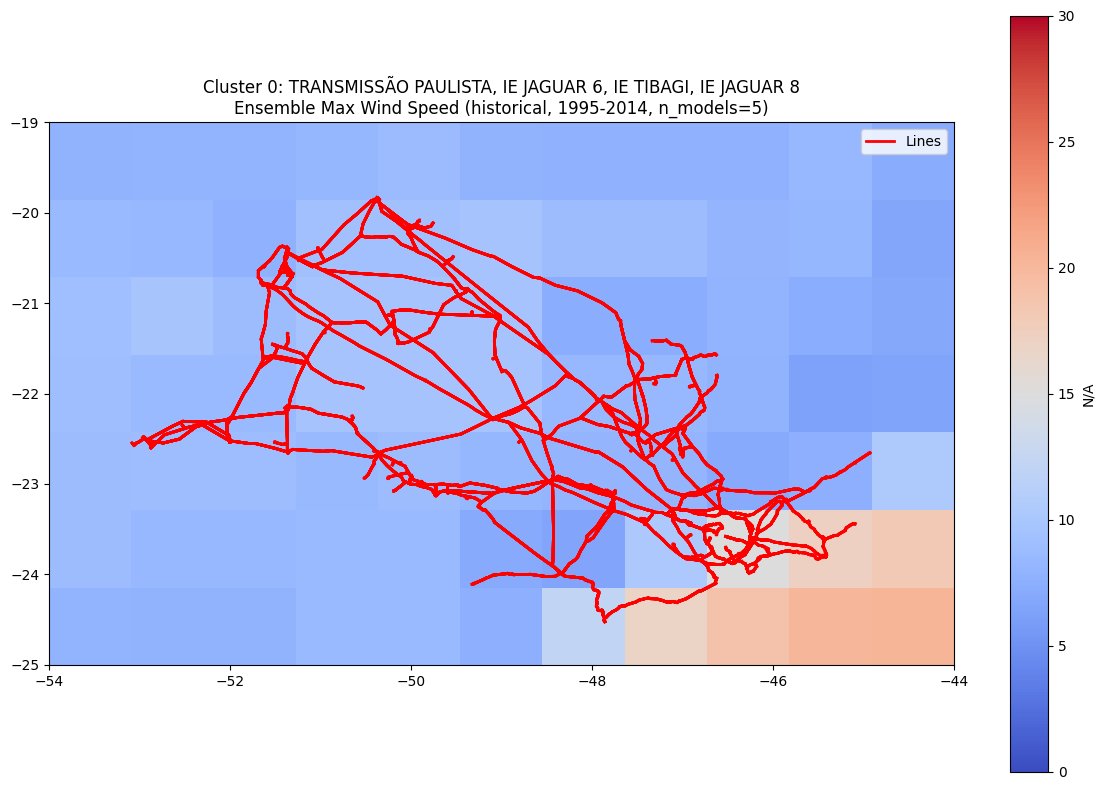

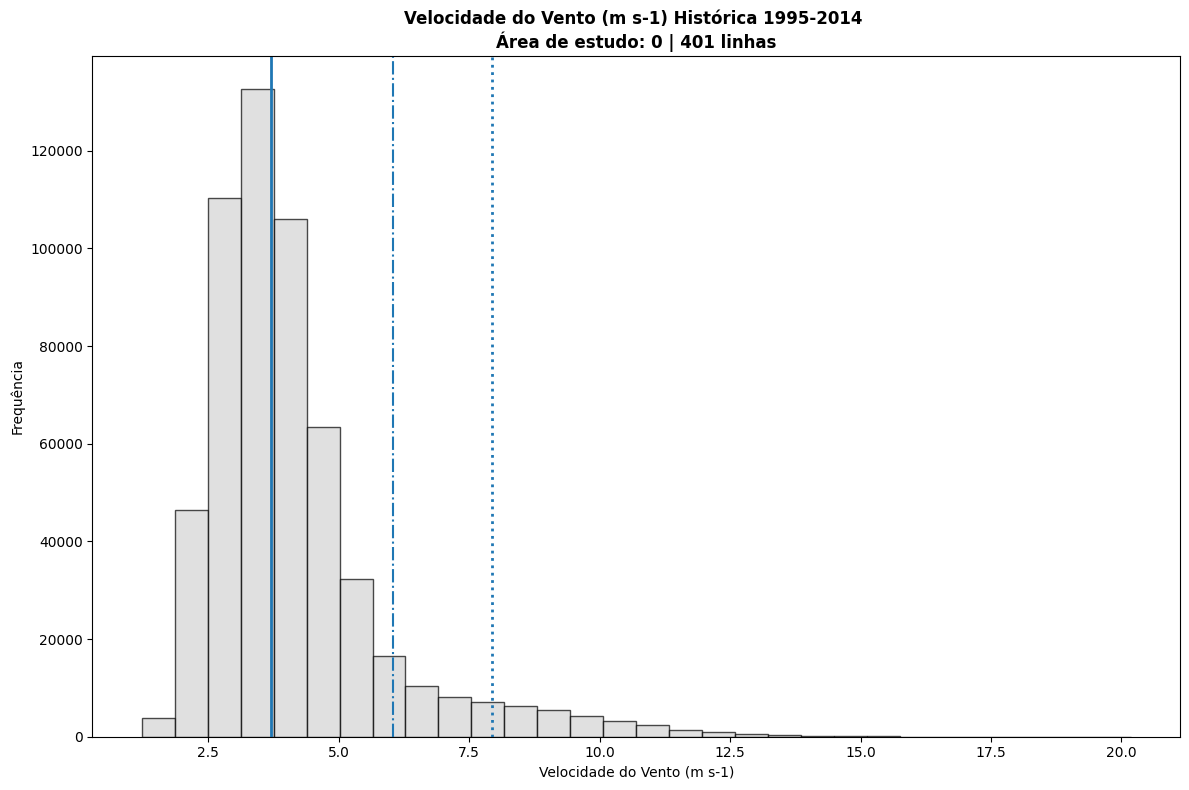

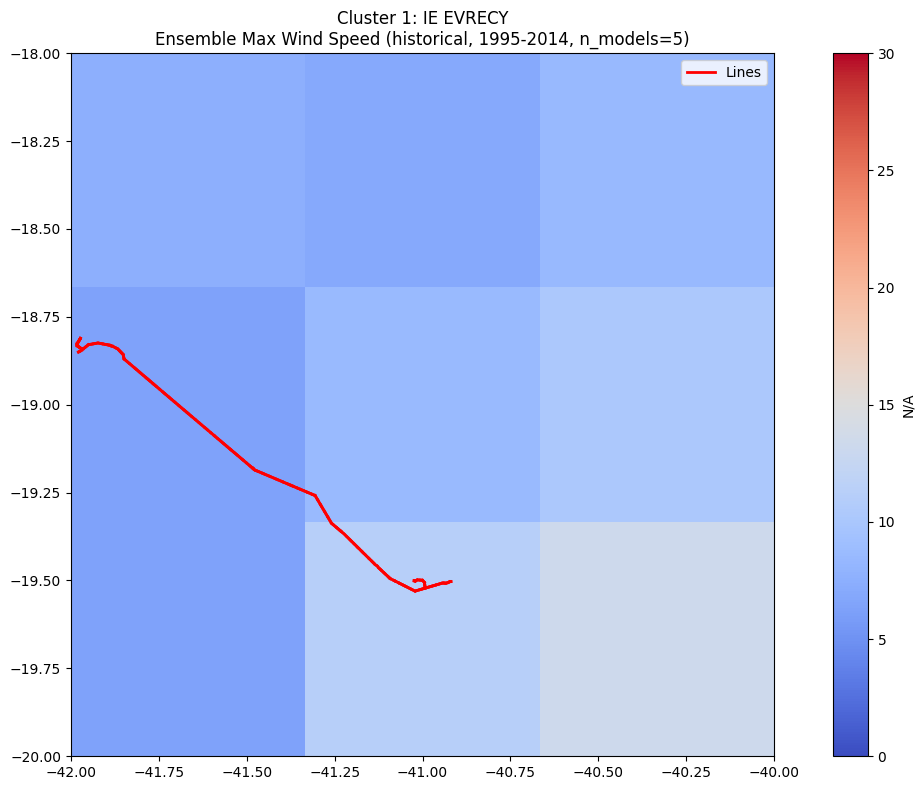

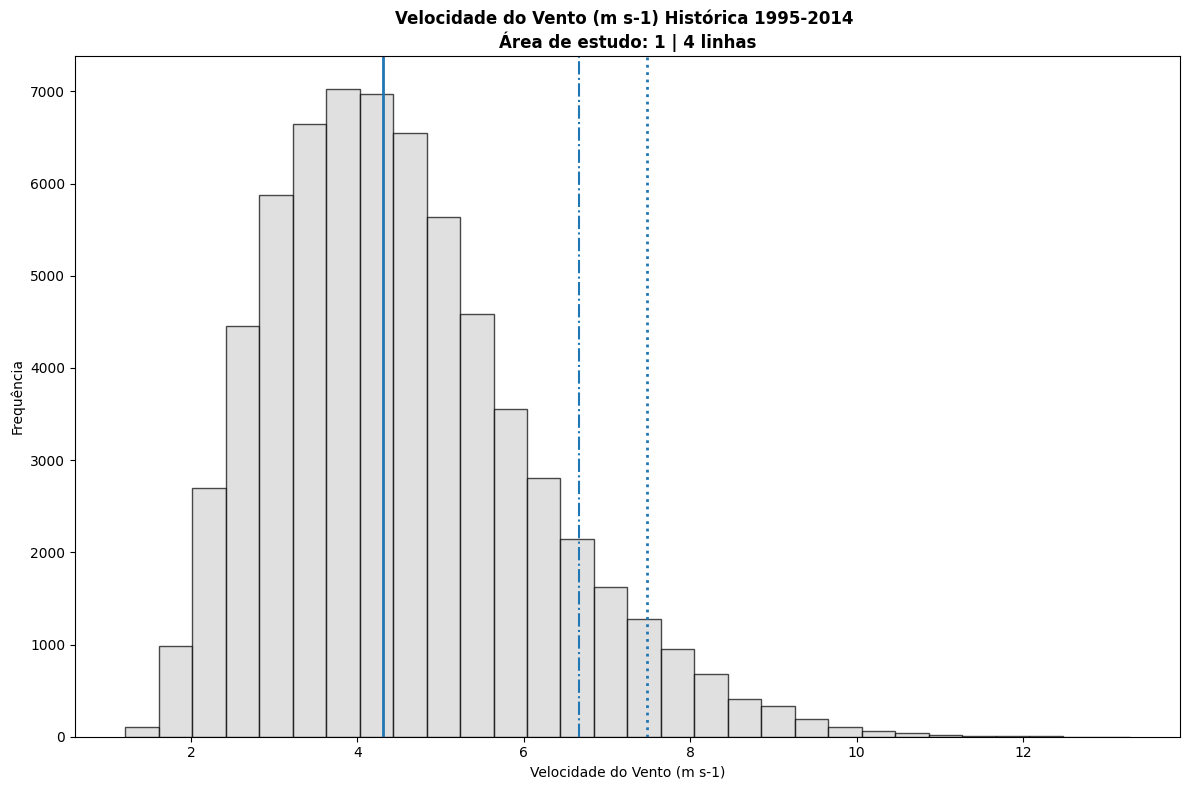

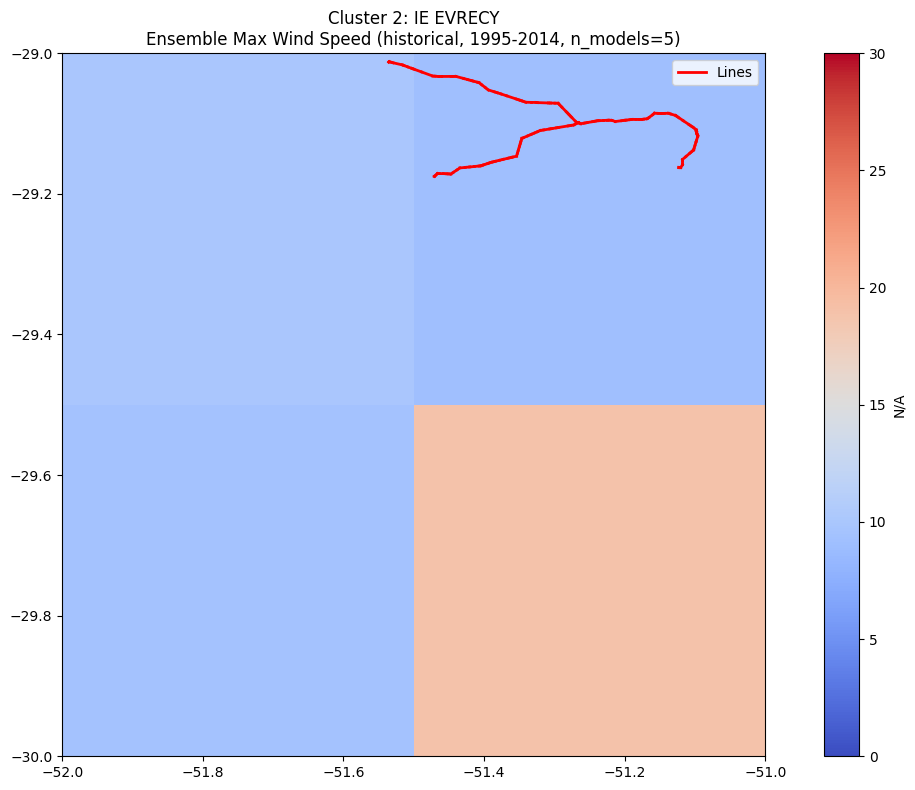

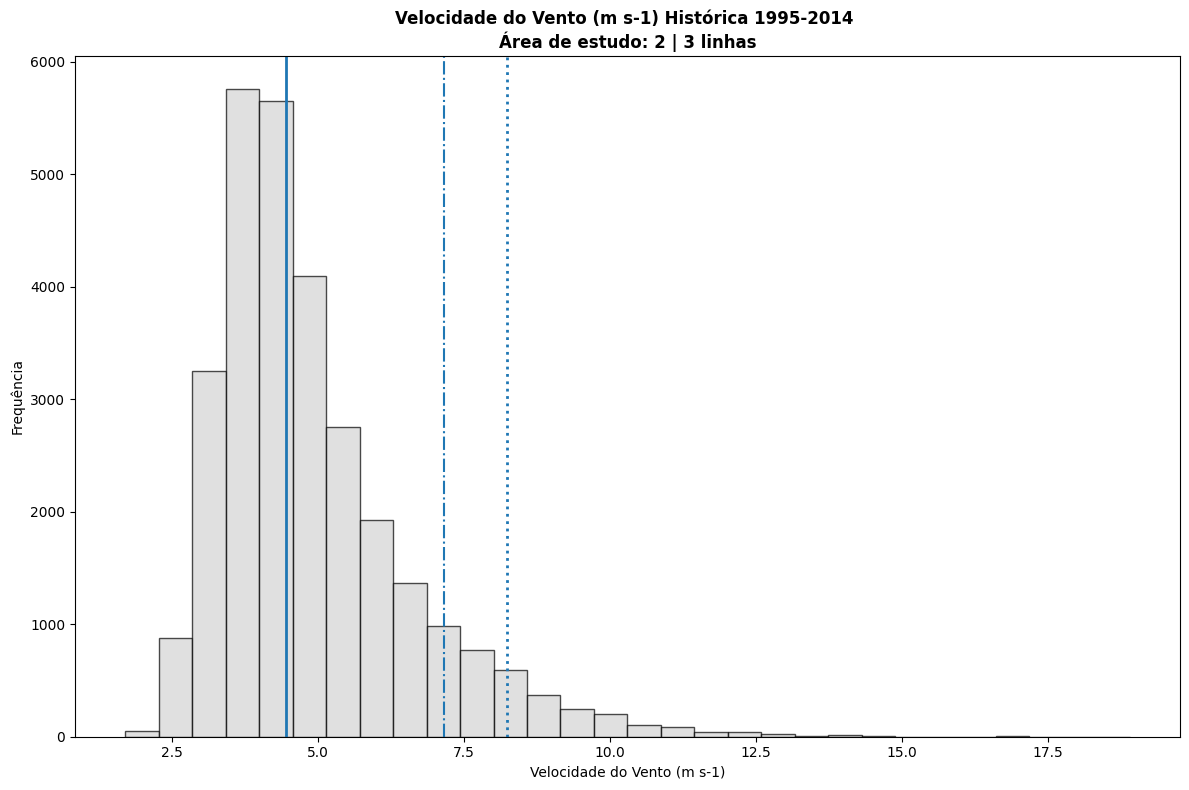

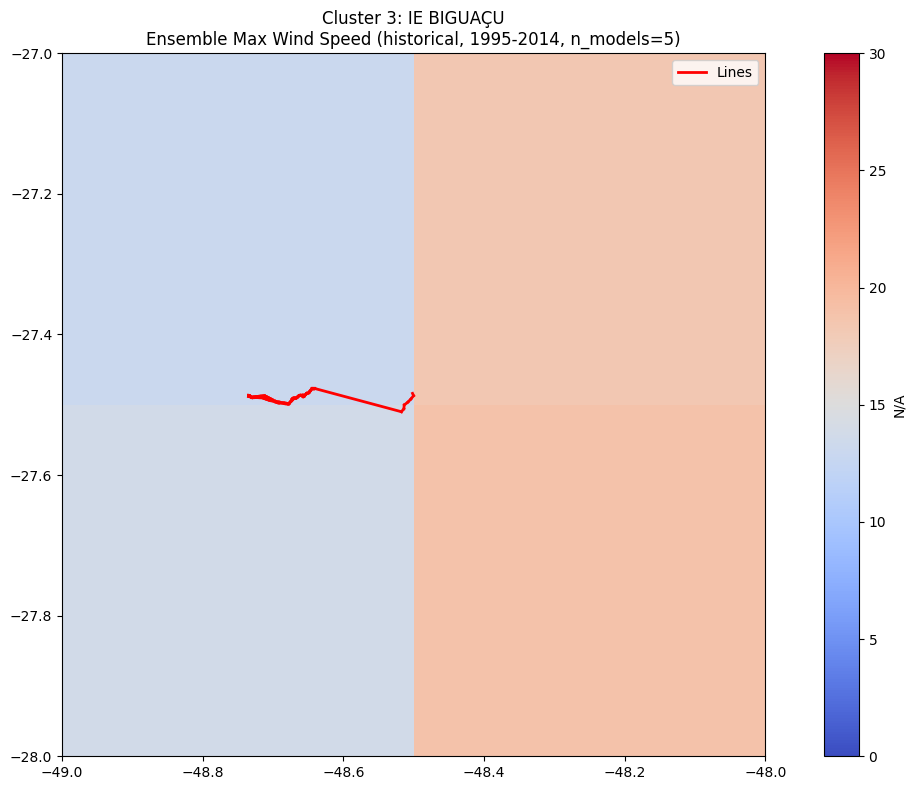

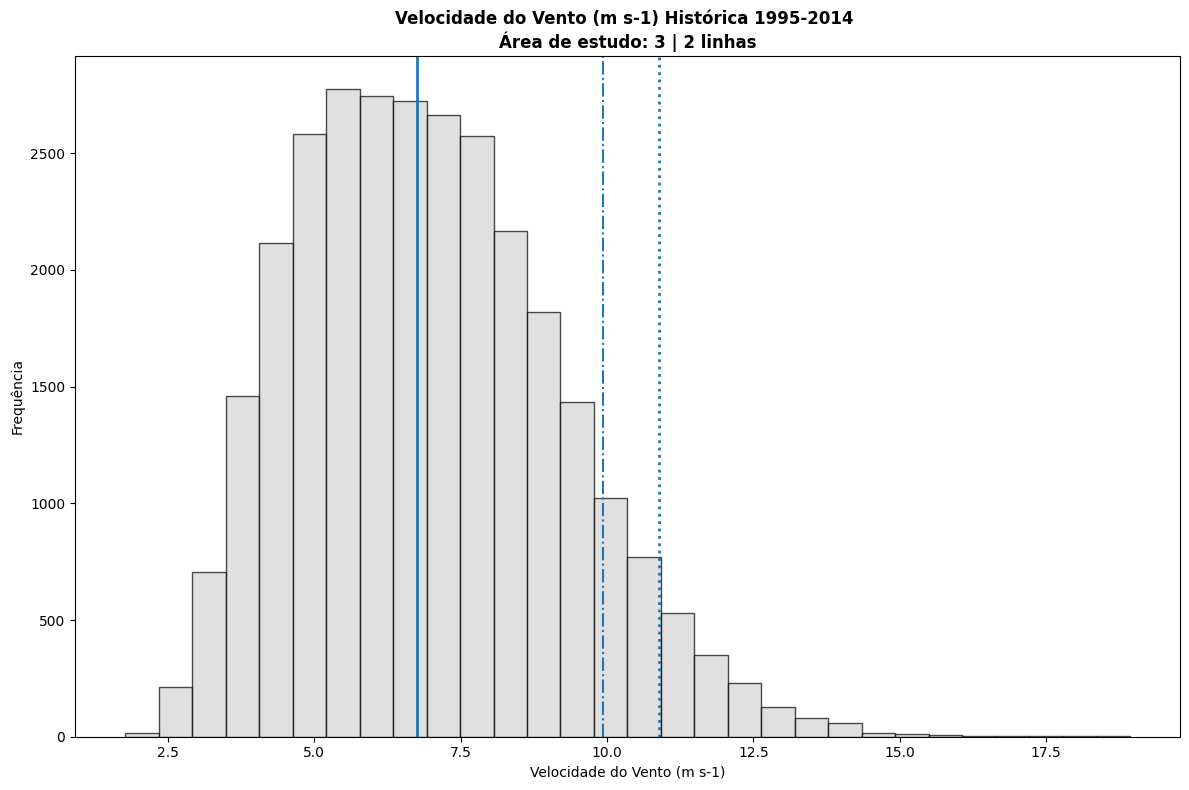

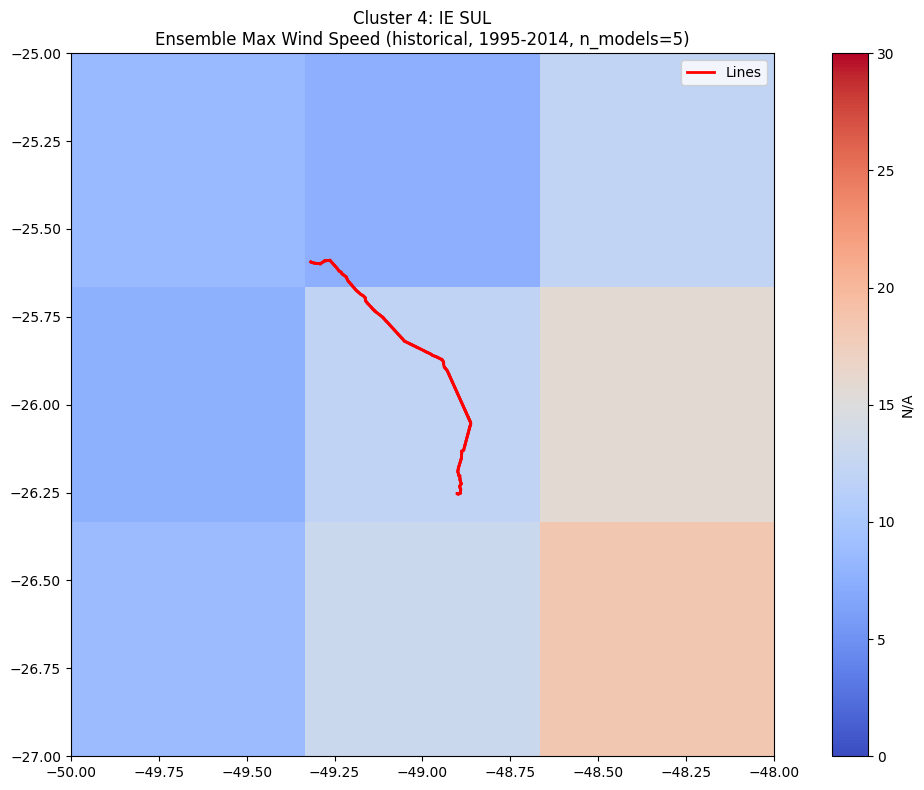

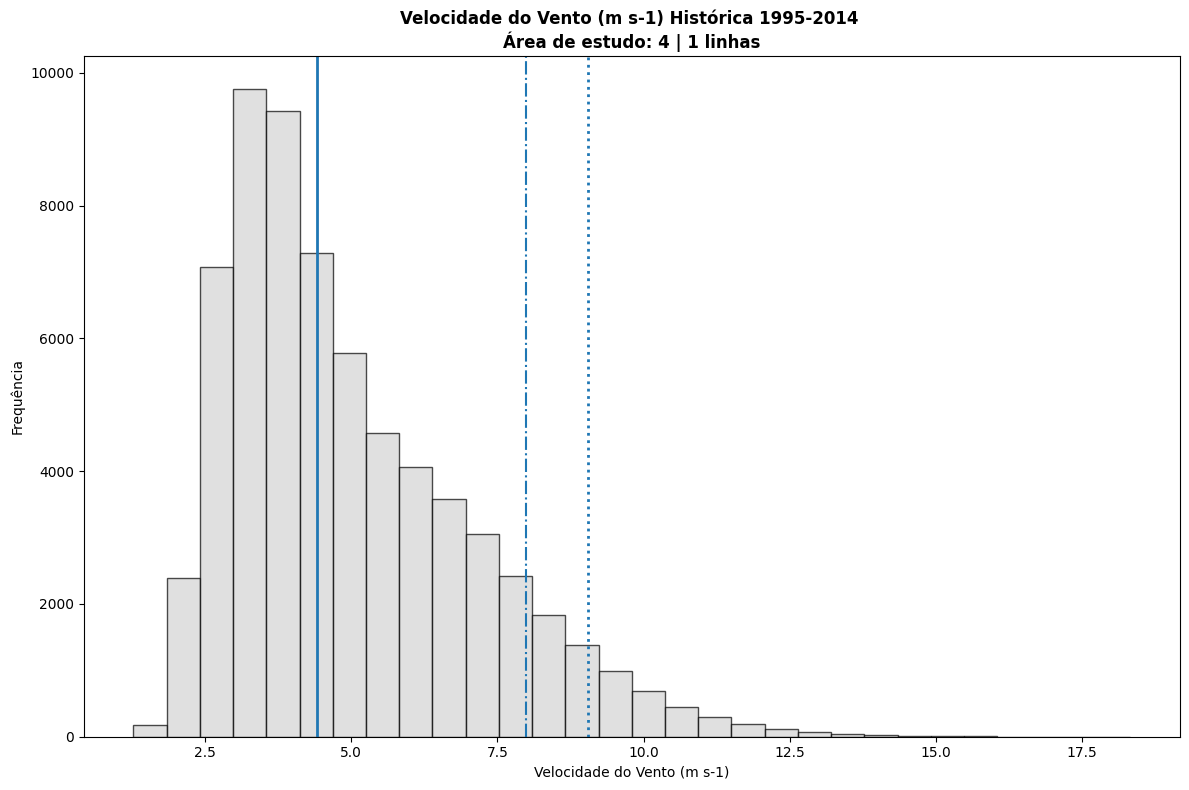

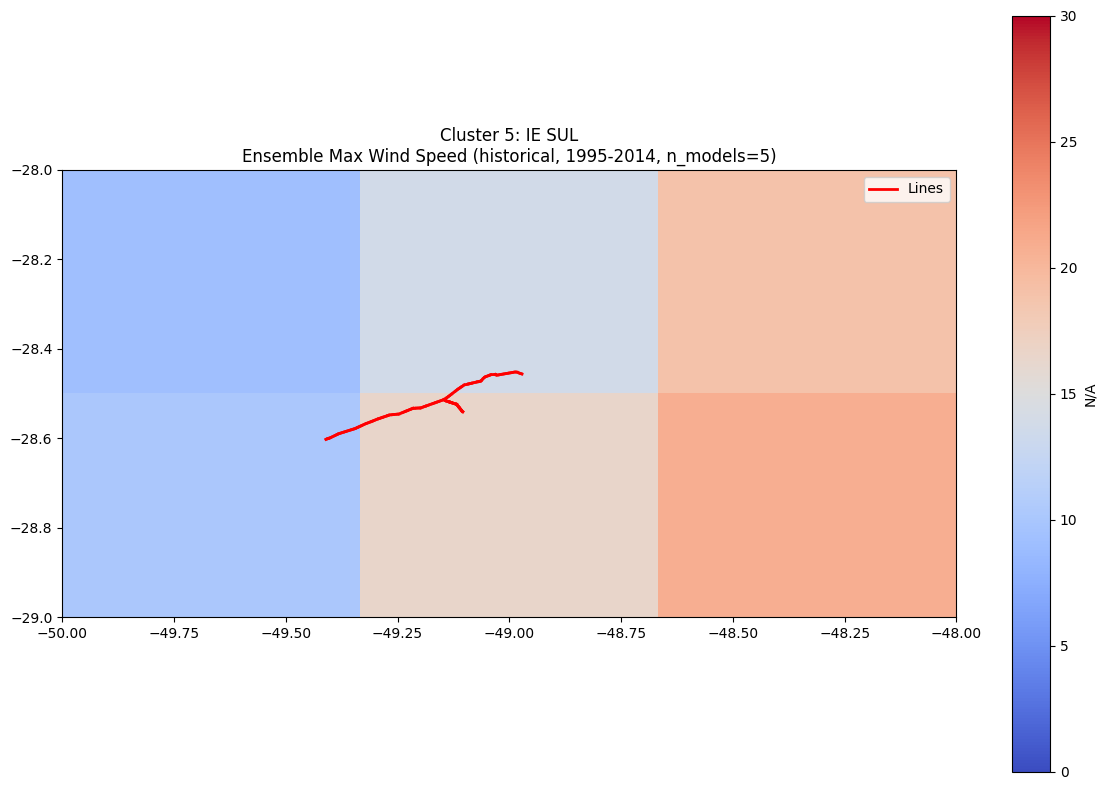

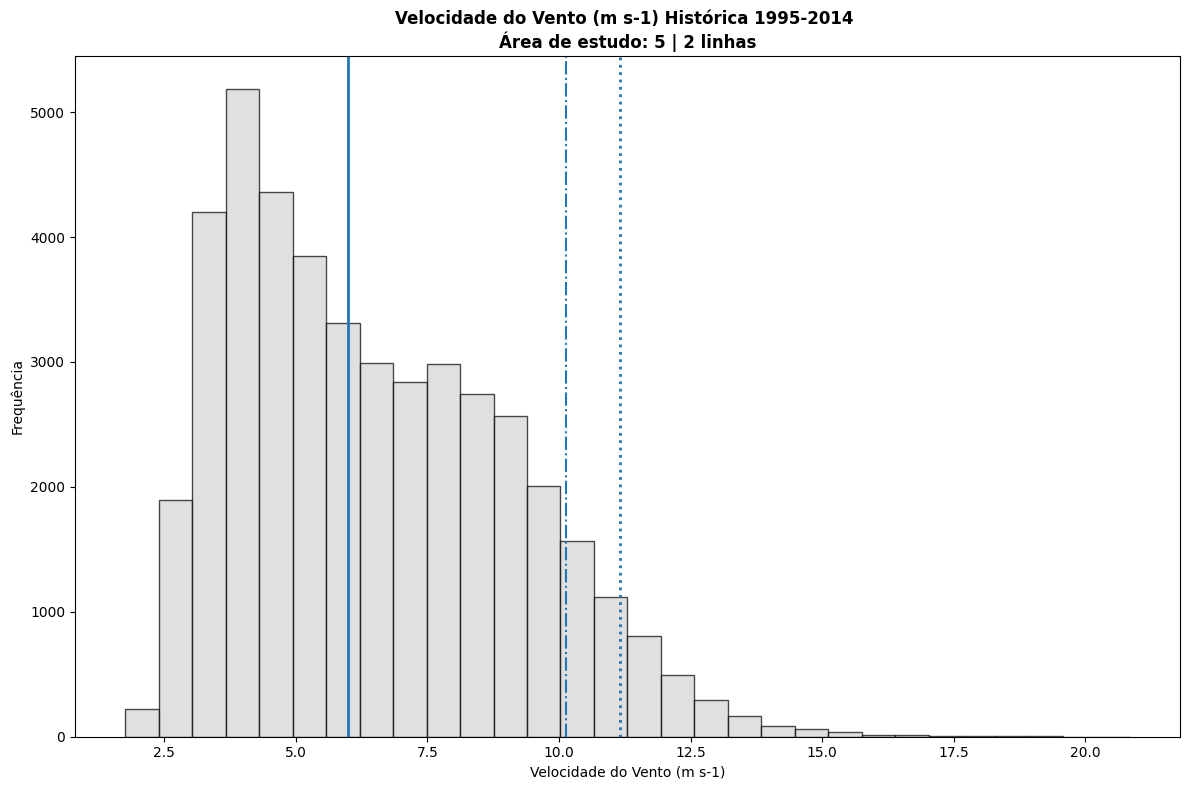

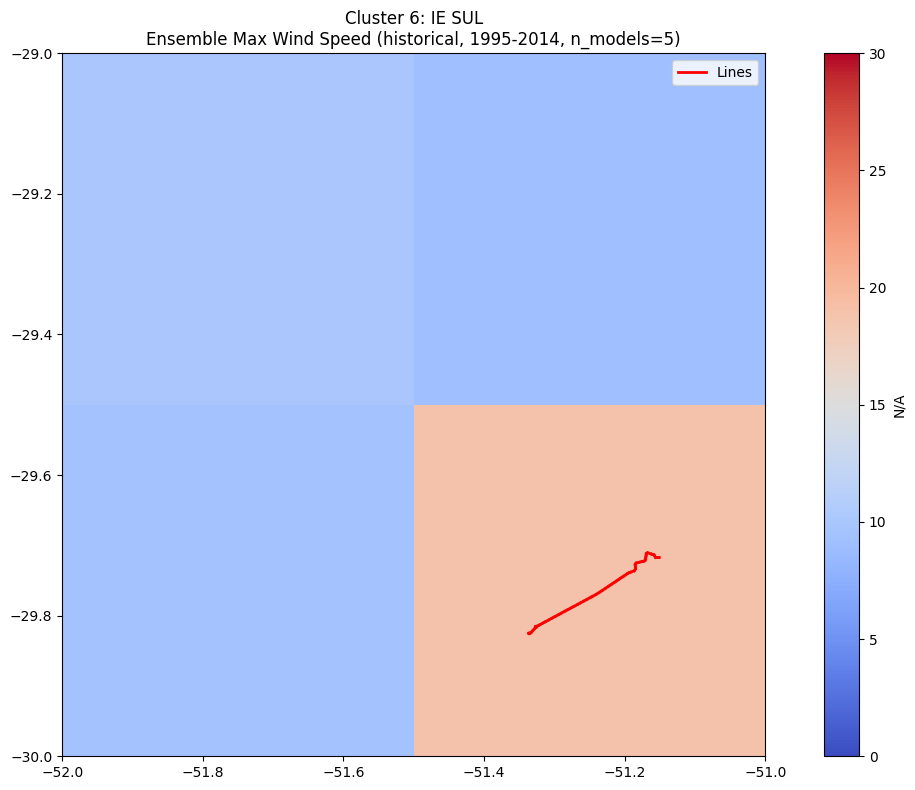

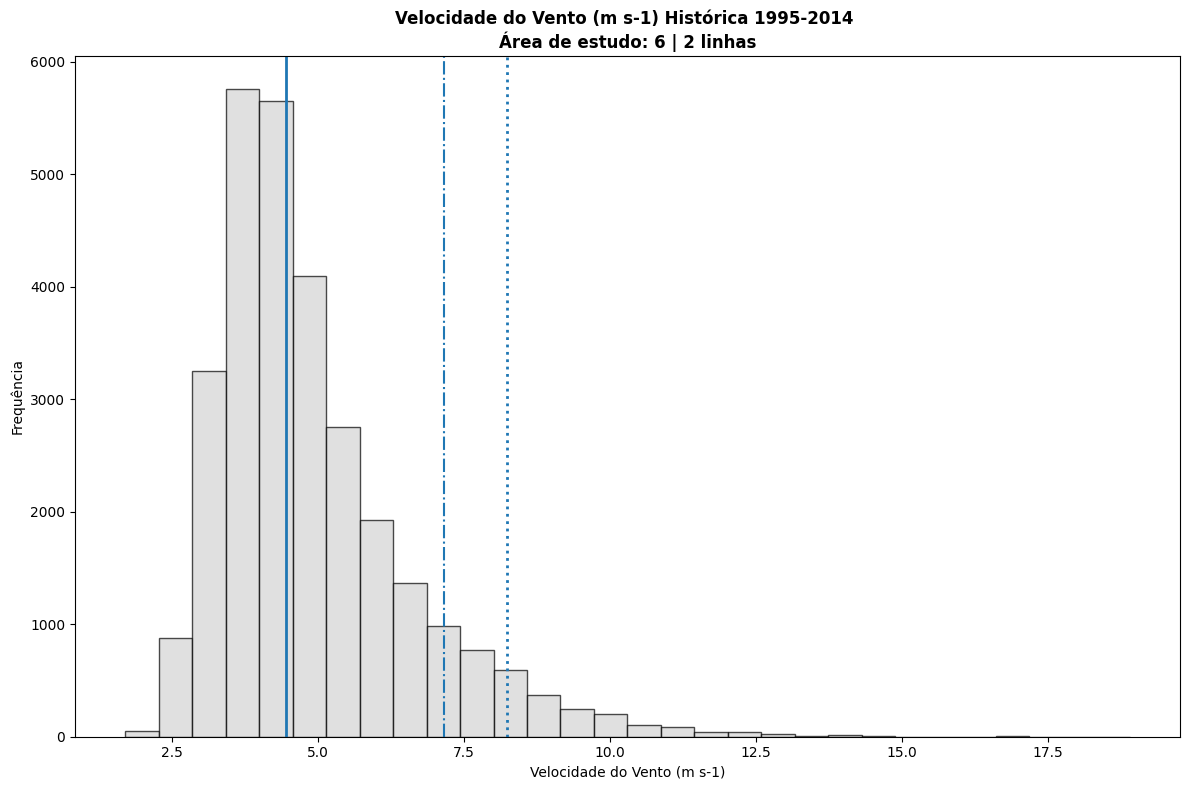

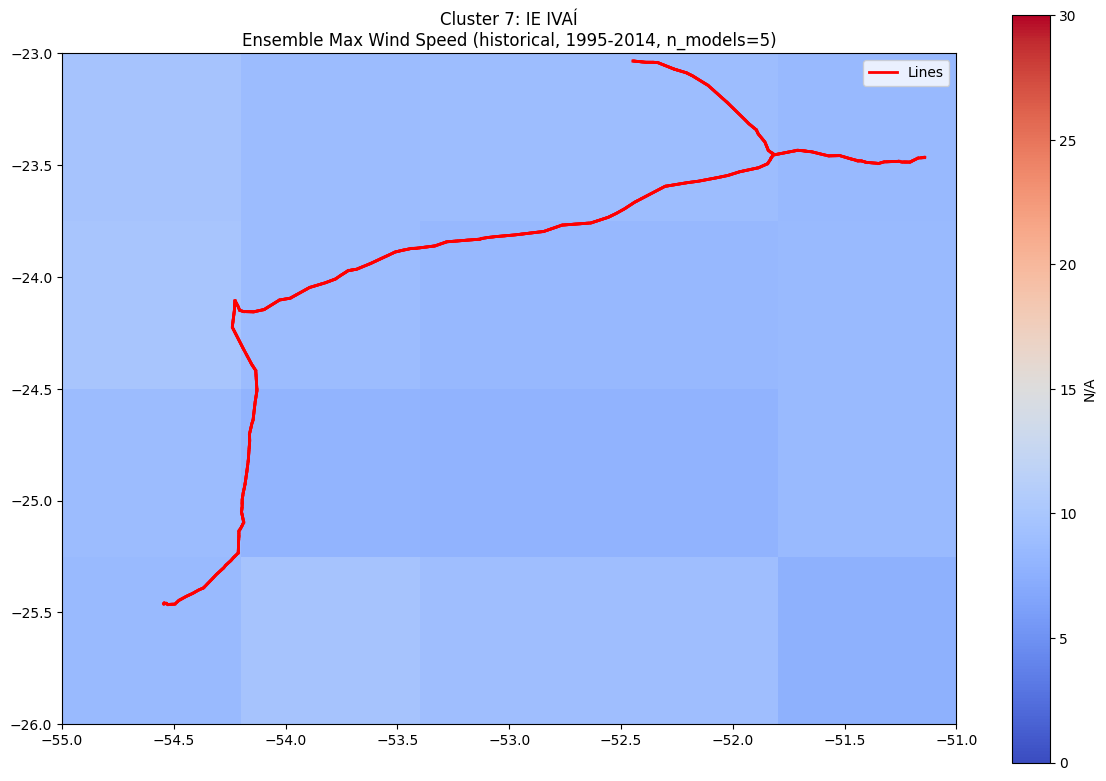

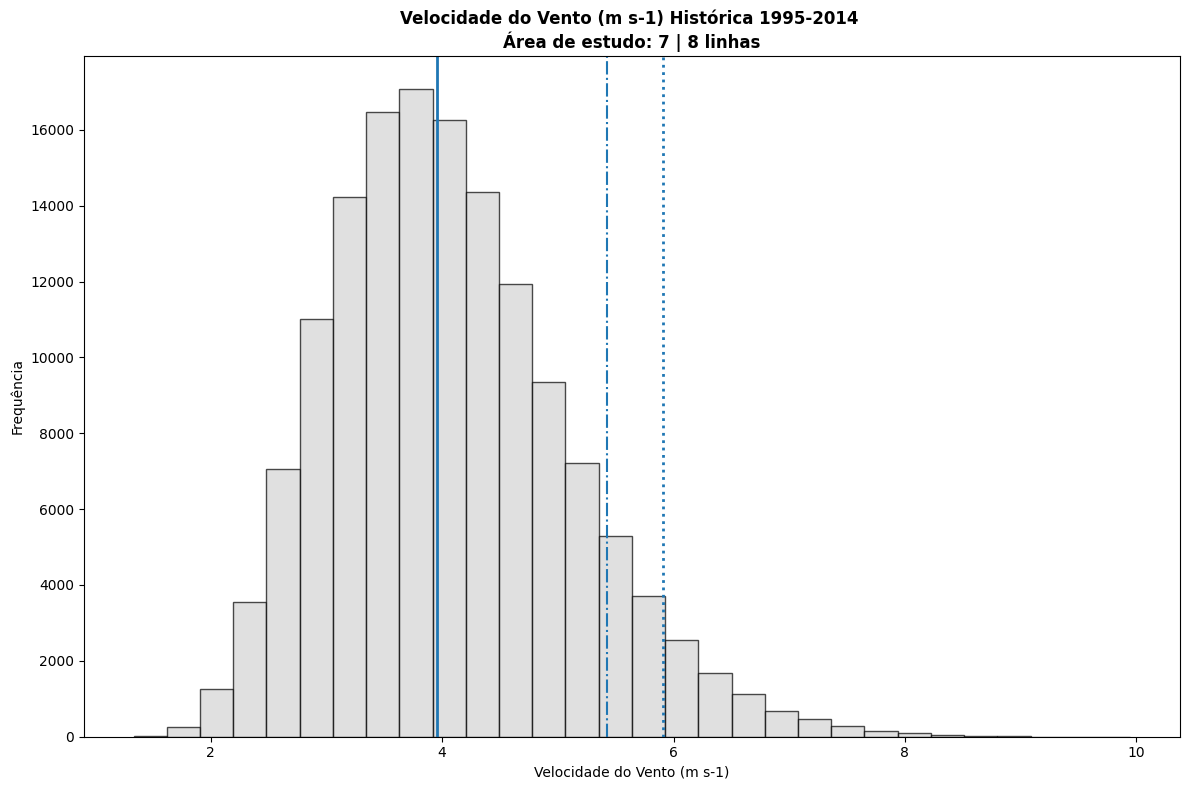

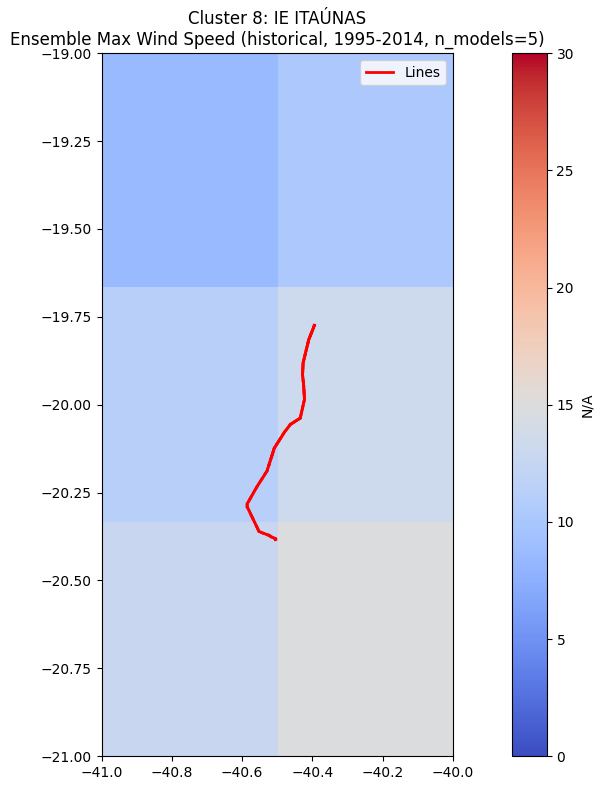

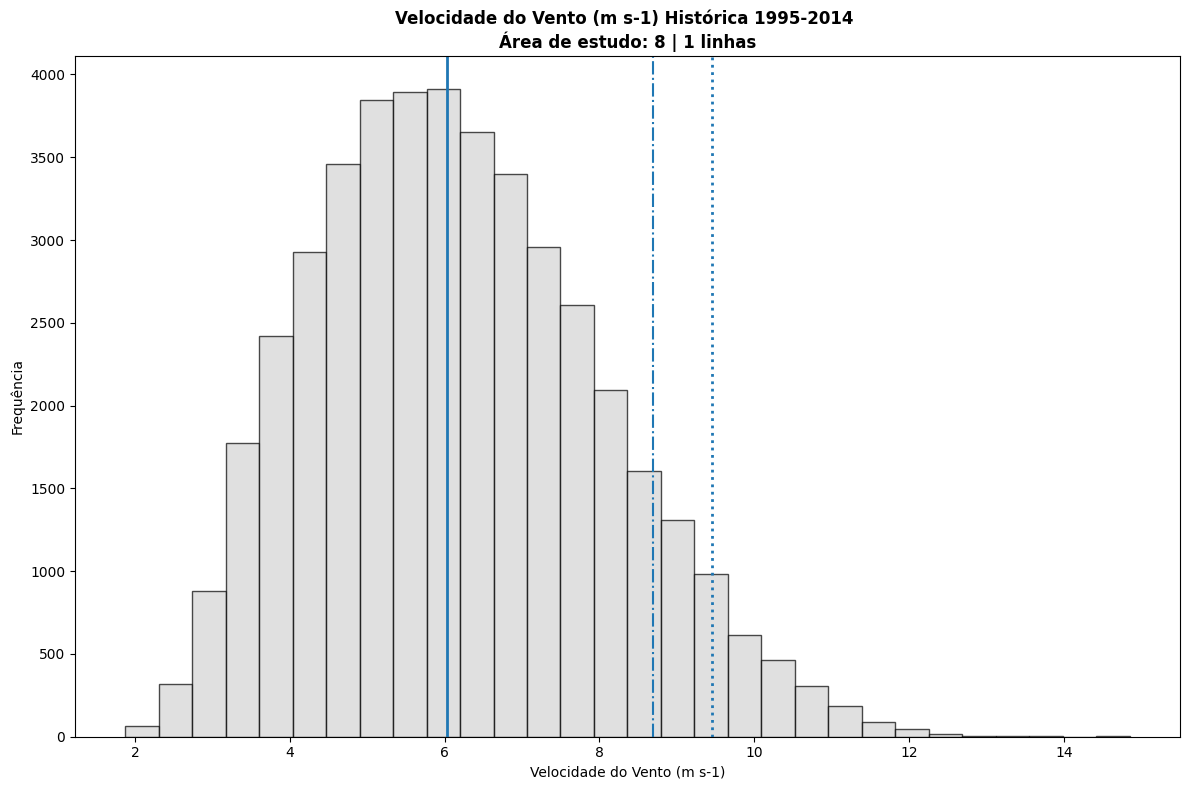

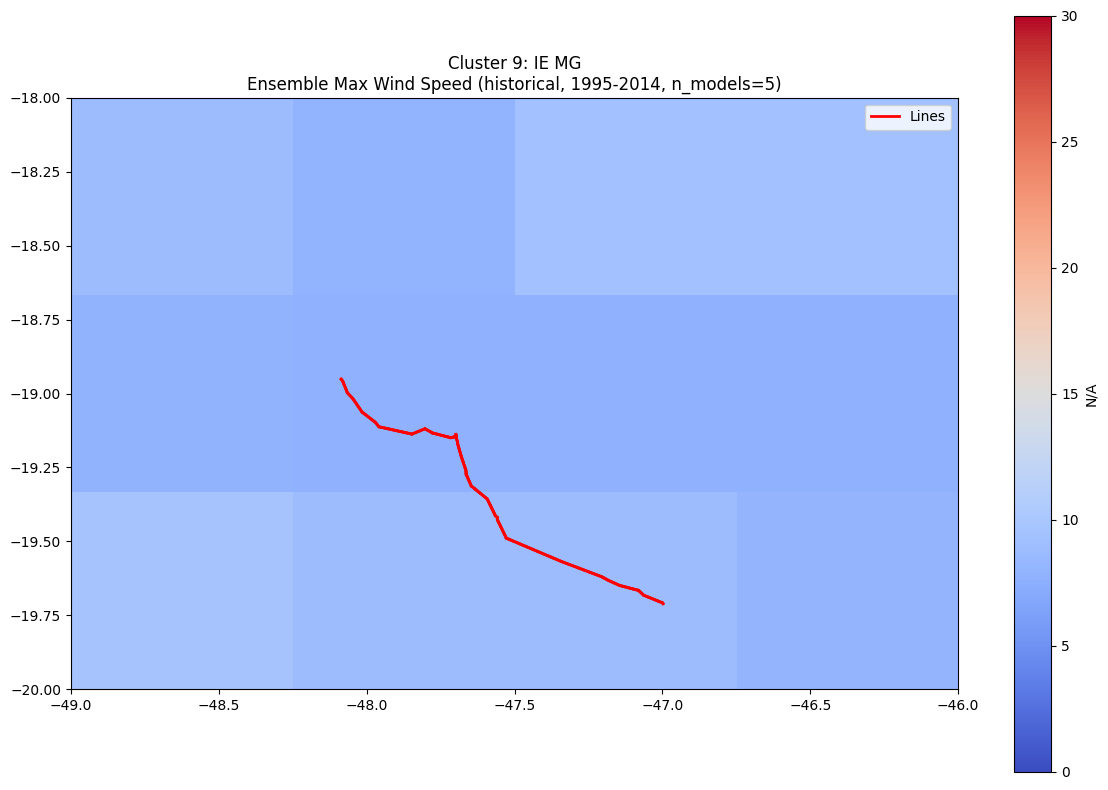

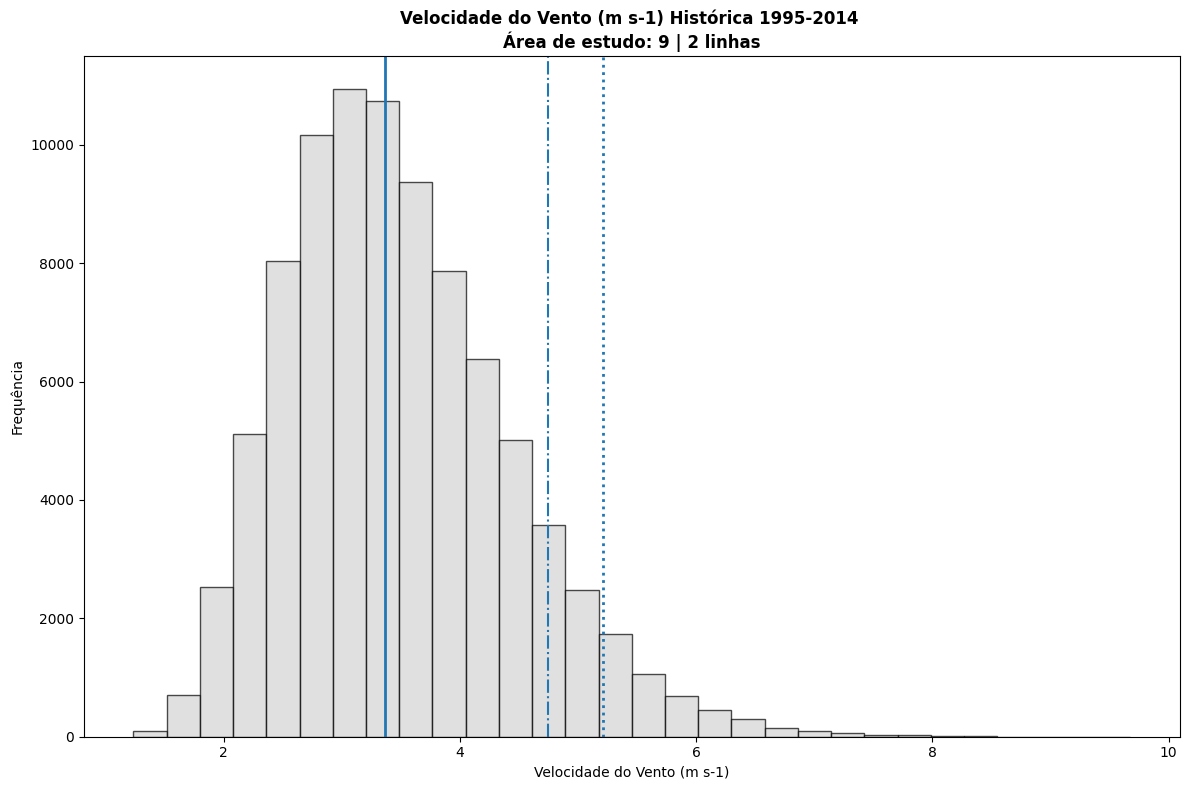

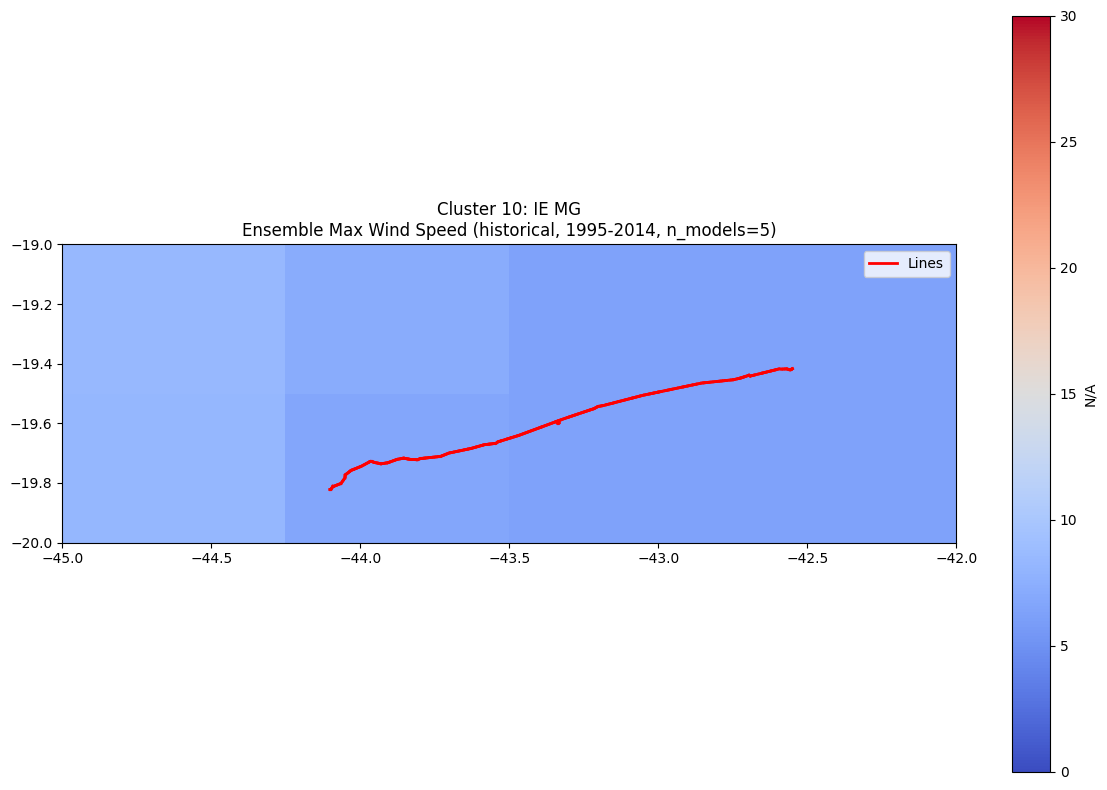

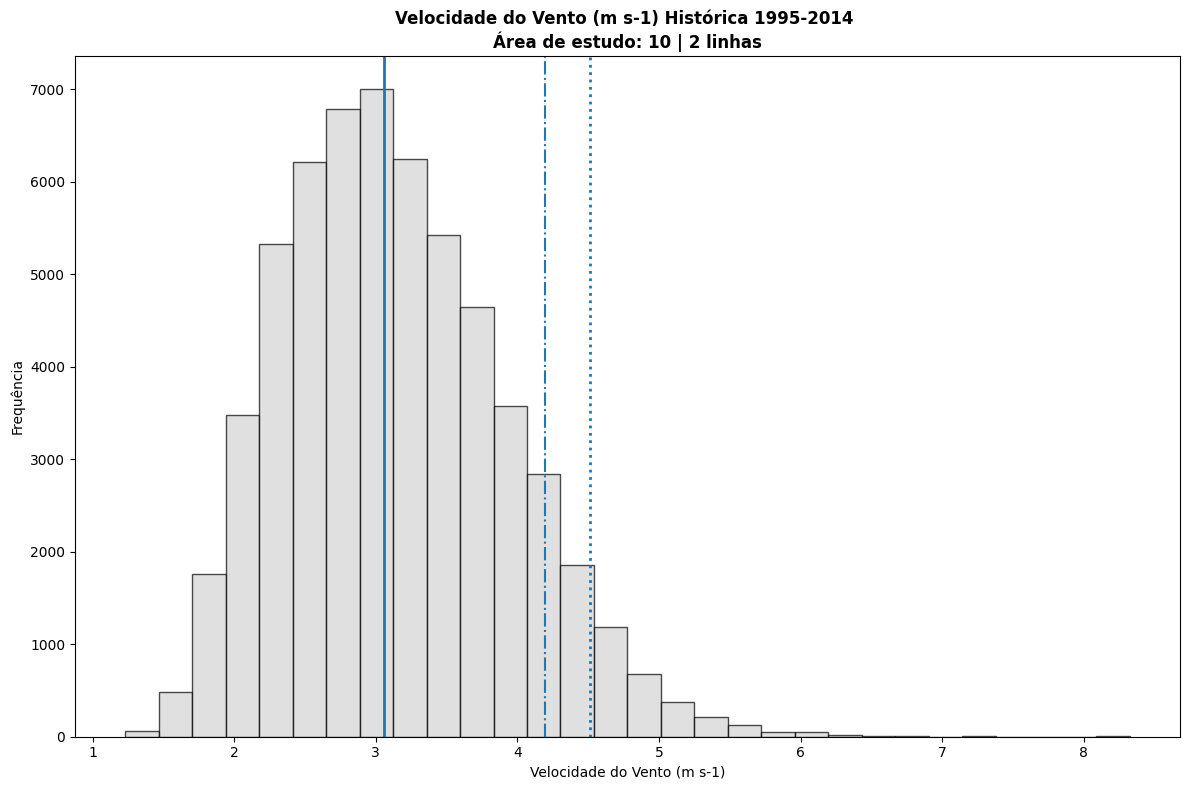

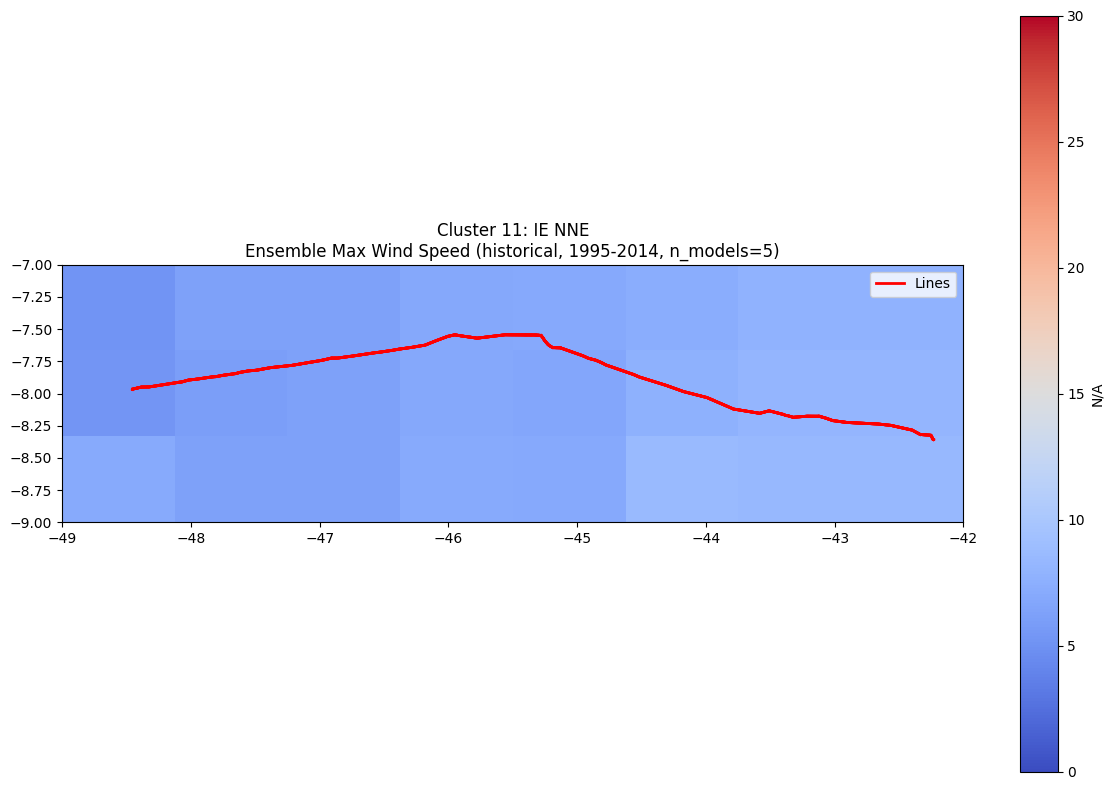

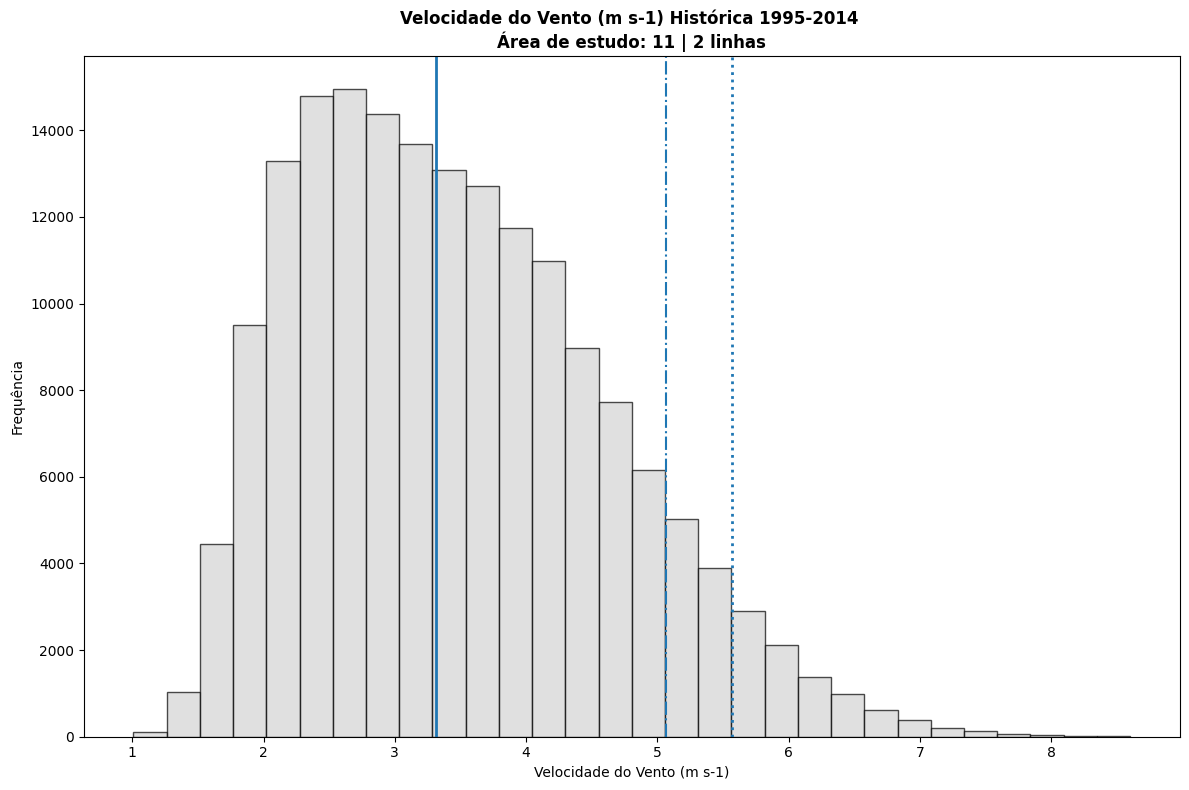

In [ ]:
for cluster, group in gdf_clustered.groupby("cluster"):

    empresas = ", ".join(group['EMPRESA'].unique())
    n_linhas = len(group['LINHA'].unique())

    raw_bounds = group.total_bounds  
    bounds = pad_bounds_km(raw_bounds, pad_km=250.0) #250km is the max resolution
    line_union = group.geometry.union_all()
    line_coords = get_line_coords(line_union)  #process lines for plotting later



    for (scenario, date_range), scenario_group in var_df.groupby(['scenario', 'date_range']):

        var_extremes = variables_extremes[CURRENT_VAR]

        cur_file = f"ensembles/{CURRENT_VAR}/ensemble_max_{scenario}_{date_range}.nc"

        with xr.open_dataset(cur_file) as ds:
            da = ds[CURRENT_VAR]
            da_subset = subset_da_to_bbox(da, lat_name, lon_name, raw_bounds)
            
            #Plot max ensemble with lines
            fig, ax = plt.subplots(figsize=(12, 8))
            im = ax.imshow(da_subset.max(dim='time'), extent=get_extent(da_subset), origin='lower', cmap='coolwarm', vmin=var_extremes[0], vmax=var_extremes[1])
            plt.colorbar(im, ax=ax, label=da.attrs.get('units', 'N/A'))

            for i, (xs, ys) in enumerate(line_coords):
                ax.plot(xs, ys, 'r-', linewidth=2, label='Lines' if i == 0 else '')

            ax.set_title(f'Cluster {cluster}: {empresas}\nEnsemble Max Wind Speed ({scenario}, {date_range}, n_models={n_models})')
            ax.legend()
            plt.tight_layout()
            plt.show()


            #plot Histogram
            values = da_subset.values.flatten() 
            values = values[np.isfinite(values)]
            values = values[~np.isnan(values)]

            # Plot histogram
            fig, ax = plt.subplots(figsize=(12, 8))

            ax.hist(values, bins=30, edgecolor='black', alpha=0.7, color='lightgray')

            # --- Stats ---
            q5, q10, q50, q90, q95 = np.percentile(values, [5, 10, 50, 90, 95])

            # --- Lines ---
            ax.axvline(q50, linestyle='-', linewidth=2, label=f"Median: {q50:.1f}")
            ax.axvline(q90, linestyle='-.', linewidth=1.5, label=f"Q90: {q90:.1f}")
            ax.axvline(q95, linestyle=':',  linewidth=2.0, label=f"Q95: {q95:.1f}")

            # Labels
            scenario = "Histórica" if scenario == "historical" else scenario.replace("_", "-", 1).replace("_", ".", 1)
            title = f"Velocidade do Vento (m s-1) {scenario} {date_range} \nÁrea de estudo: {cluster} | {n_linhas} linhas"
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel("Velocidade do Vento (m s-1)")
            ax.set_ylabel("Frequência")
            plt.tight_layout()
            plt.show()

            break
    


In [13]:
# min_da = 0
# max_da = 0
# for cluster, group in gdf_clustered.groupby("cluster"):
    
#     empresas = ", ".join(group['EMPRESA'].unique())
#     n_linhas = len(group['LINHA'].unique())

#     raw_bounds = group.total_bounds  # [lon_min, lat_min, lon_max, lat_max]
#     bounds = pad_bounds_km(raw_bounds, pad_km=250.0)
#     line_union = group.geometry.union_all()

#     line_coords = []

#     if line_union.geom_type == 'MultiLineString':
#         for line in line_union.geoms:
#             line_coords.append(line.xy)
#     else:
#         line_coords.append(line_union.xy)

#     for (scenario, date_range), scenario_group in var_df.groupby(['scenario', 'date_range']):
#         n_models = len(scenario_group)

#         # Defina sua grade alvo ANTES do loop (ex: 1.0 grau)
#         target_lat = np.arange(bounds[1], bounds[3], 1)
#         target_lon = np.arange(bounds[0], bounds[2], 1)
#         time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

#         model_results = []


#         for i in range(len(scenario_group)):
#             variable_name = 'sfcWind'
#             lat_name, lon_name = 'lat','lon'
            
#             ds = xr.open_dataset(
#                 scenario_group.iloc[i]["filepath"], 
#                 decode_times=time_coder
#             )
            
#             ds['time'] = ds.indexes['time'].to_datetimeindex(time_unit='ns')
            
#             da = ds[variable_name]

#             min_da = min(min_da, da.min().item())
#             max_da = max(max_da, da.max().item())
#             print(f"Updated global min/max: {min_da:.2f} / {max_da:.2f}")
            
#             da_subset = subset_da_to_bbox(da, lat_name, lon_name, bounds)
#             ds_interp = da_subset.interp(lat=target_lat, lon=target_lon, method='linear')
#             model_results.append(ds_interp)

#             # plt.figure(figsize=(12, 5))

#             # # Plot 1: Original (usando os limites reais do subset)
#             # plt.subplot(1, 2, 1)
#             # plt.title("Original Subset (Real Coords)")
#             # ext_orig = get_extent(da_subset)
#             # plt.imshow(da_subset[0], extent=ext_orig, origin='lower', vmin=0, vmax=10)
#             # plt.colorbar(label=da_subset.units)

#             # for i, (xs, ys) in enumerate(line_coords):
#             #     plt.plot(xs, ys, 'r-', linewidth=2, label='Lines' if i == 0 else '')

#             # # Plot 2: Interpolado (usando os limites da grade alvo)
#             # plt.subplot(1, 2, 2)
#             # plt.title("Interpolated (Target Coords)")
#             # ext_interp = get_extent(ds_interp)
#             # plt.imshow(ds_interp[0], extent=ext_interp, origin='lower', vmin=0, vmax=10)
#             # plt.colorbar(label=da_subset.units)

#             # for i, (xs, ys) in enumerate(line_coords):
#             #     plt.plot(xs, ys, 'r-', linewidth=2, label='Lines' if i == 0 else '')

#             # plt.tight_layout()
#             # plt.show()


#         ensemble_cube = xr.concat(model_results, dim='model')
#         ensemble_max = ensemble_cube.max(dim='model', skipna=True)
#         ensemble_max = subset_da_to_bbox(ensemble_max, lat_name, lon_name, raw_bounds)

#         fig, ax = plt.subplots(figsize=(12, 8))

#         # Plot ensemble_max 
#         im = ax.imshow(ensemble_max.max(dim='time'), extent=get_extent(ensemble_max), origin='lower', cmap='coolwarm', vmin=0, vmax=30)
#         plt.colorbar(im, ax=ax, label=da.attrs.get('units', 'N/A'))

#         for i, (xs, ys) in enumerate(line_coords):
#             ax.plot(xs, ys, 'r-', linewidth=2, label='Lines' if i == 0 else '')

#         ax.set_title(f'Cluster {cluster}: {empresas}\nEnsemble Max Wind Speed ({scenario}, {date_range}, n_models={n_models})')
#         ax.legend()
#         plt.tight_layout()
#         plt.show()
